In [1]:
import os
import numpy as np
from collections import Counter

base_path = "/mnt/d/Hoc_tap_Sinh_Vien/Kien_thu_AI/Project/Duration_edge_ai/data/processed/dataMel"

def load_mel_shapes(base_path):
    shapes_info = []
    class_counts = {} 

    for label, category in enumerate(['xanh', 'chin']):
        folder_path = os.path.join(base_path, category)

        if not os.path.exists(folder_path):
            print(f"Không tìm thấy thư mục: {folder_path}")
            continue

        files = [f for f in os.listdir(folder_path) if f.endswith('.npy')]
        class_counts[category] = len(files)
        print(f"{category} (Label {label}): {len(files)} files")

        for file in files:
            file_path = os.path.join(folder_path, file)
            try:
                # Chỉ cần đọc metadata để lấy shape (rất nhẹ RAM)
                mel_spec = np.load(file_path, mmap_mode='r')
                shapes_info.append((category, file, mel_spec.shape))
            except Exception as e:
                print(f"Lỗi {file}: {e}")

    return shapes_info, class_counts

shapes_info, class_counts = load_mel_shapes(base_path)
print(f"\nĐã kiểm tra {len(shapes_info)} ma trận mel")

# Phân phối dữ liệu (Check mất cân bằng)
print("\nPhân phối dữ liệu theo lớp:")
for cls, count in class_counts.items():
    print(f"   - {cls}: {count} files")

# Các shape khác nhau
unique_shapes = {shape for _, _, shape in shapes_info}
print(f"\nCác shape khác nhau: {unique_shapes}")

shape_counts = Counter(shape for _, _, shape in shapes_info)
print("\nPhân phối shape:")
for shape, count in shape_counts.items():
    print(f"   - {shape}: {count} files ({count / len(shapes_info) * 100:.1f}%)")


xanh (Label 0): 889 files
chin (Label 1): 236 files

Đã kiểm tra 1125 ma trận mel

Phân phối dữ liệu theo lớp:
   - xanh: 889 files
   - chin: 236 files

Các shape khác nhau: {(128, 12), (128, 19), (128, 11)}

Phân phối shape:
   - (128, 19): 1123 files (99.8%)
   - (128, 11): 1 files (0.1%)
   - (128, 12): 1 files (0.1%)


In [2]:
import os
import numpy as np
from sklearn.preprocessing import LabelEncoder

N_MELS = 128

class MelDataLoader:
    def __init__(self, data_dir):
        self.data_dir = data_dir
        self.label_encoder = LabelEncoder()

    def load_data(self):
        X_list = []
        y_list = []

        for label in ['xanh', 'chin']:
            folder_path = os.path.join(self.data_dir, label)
            if not os.path.isdir(folder_path):
                print(f"Không tìm thấy thư mục: {folder_path}")
                continue

            files = [f for f in os.listdir(folder_path) if f.endswith('.npy')]
            print(f"\n {label}: {len(files)} files")

            for file in files:
                file_path = os.path.join(folder_path, file)
                try:
                    data = np.load(file_path)
                    if data.ndim != 2:
                        continue
                    if data.shape[0] != N_MELS and data.shape[1] == N_MELS:
                        data = data.T
                    if data.shape[0] == N_MELS:
                        X_list.append(data)
                        y_list.append(label)

                except Exception as e:
                    print(f"Lỗi {label}/{file}: {e}")

        if not X_list:
            print("Không có dữ liệu hợp lệ!")
            return None, None

        # 1. Tìm độ dài thời gian lớn nhất
        target_time = max(x.shape[1] for x in X_list)
        print(f"\n n_mels: {N_MELS}")
        print(f"target_time: {target_time}")

        # 2. Lọc các mel không đạt yêu cầu và các nhãn tương ứng
        X_filtered = []
        y_filtered = []
        for i in range(len(X_list)):
            if X_list[i].shape[1] == target_time:
                X_filtered.append(X_list[i])
                y_filtered.append(y_list[i])

        # Cập nhật X_list và y_list với dữ liệu đã lọc
        X_list = X_filtered
        y_list = y_filtered

        if not X_list:
            print("Không có dữ liệu hợp lệ sau khi lọc theo target_time!")
            return None, None

        X = np.asarray(X_list, dtype=np.float32)
        y = self.label_encoder.fit_transform(y_list)
        print(f"Mapping nhãn: {dict(zip(self.label_encoder.classes_, self.label_encoder.transform(self.label_encoder.classes_)))}")

        X = (X - np.min(X)) / (np.max(X) - np.min(X))    # chuẩn hóa ( đưa về dạng chạy từ 0 đến 1)
        X = np.expand_dims(X, axis=-1)                   #thêm chiều

        print("\n LOAD COMPLETE!")
        print(f"   - Total samples: {len(X)}")
        print(f"   - X shape: {X.shape}")
        print(f"   - y shape: {y.shape}")

        unique, counts = np.unique(y, return_counts=True)
        for label, count in zip(unique, counts):
            print(f"   - {label}: {count} files ({count / len(y) * 100:.1f}%) ")
        return X, y

loader = MelDataLoader(base_path)
X, y = loader.load_data()


 xanh: 889 files

 chin: 236 files

 n_mels: 128
target_time: 19
Mapping nhãn: {np.str_('chin'): np.int64(0), np.str_('xanh'): np.int64(1)}

 LOAD COMPLETE!
   - Total samples: 1123
   - X shape: (1123, 128, 19, 1)
   - y shape: (1123,)
   - 0: 236 files (21.0%) 
   - 1: 887 files (79.0%) 


######## Phân tích theo năng lượng


   CHIN (Label 1):
      - Số mẫu: 887 (79.0%)
      - Mean: 0.6735
      - Std: 0.1826
      - Min: 0.0000
      - Max: 1.0000

   XANH (Label 0):
      - Số mẫu: 236 (21.0%)
      - Mean: 0.6673
      - Std: 0.1839
      - Min: 0.0000
      - Max: 1.0000


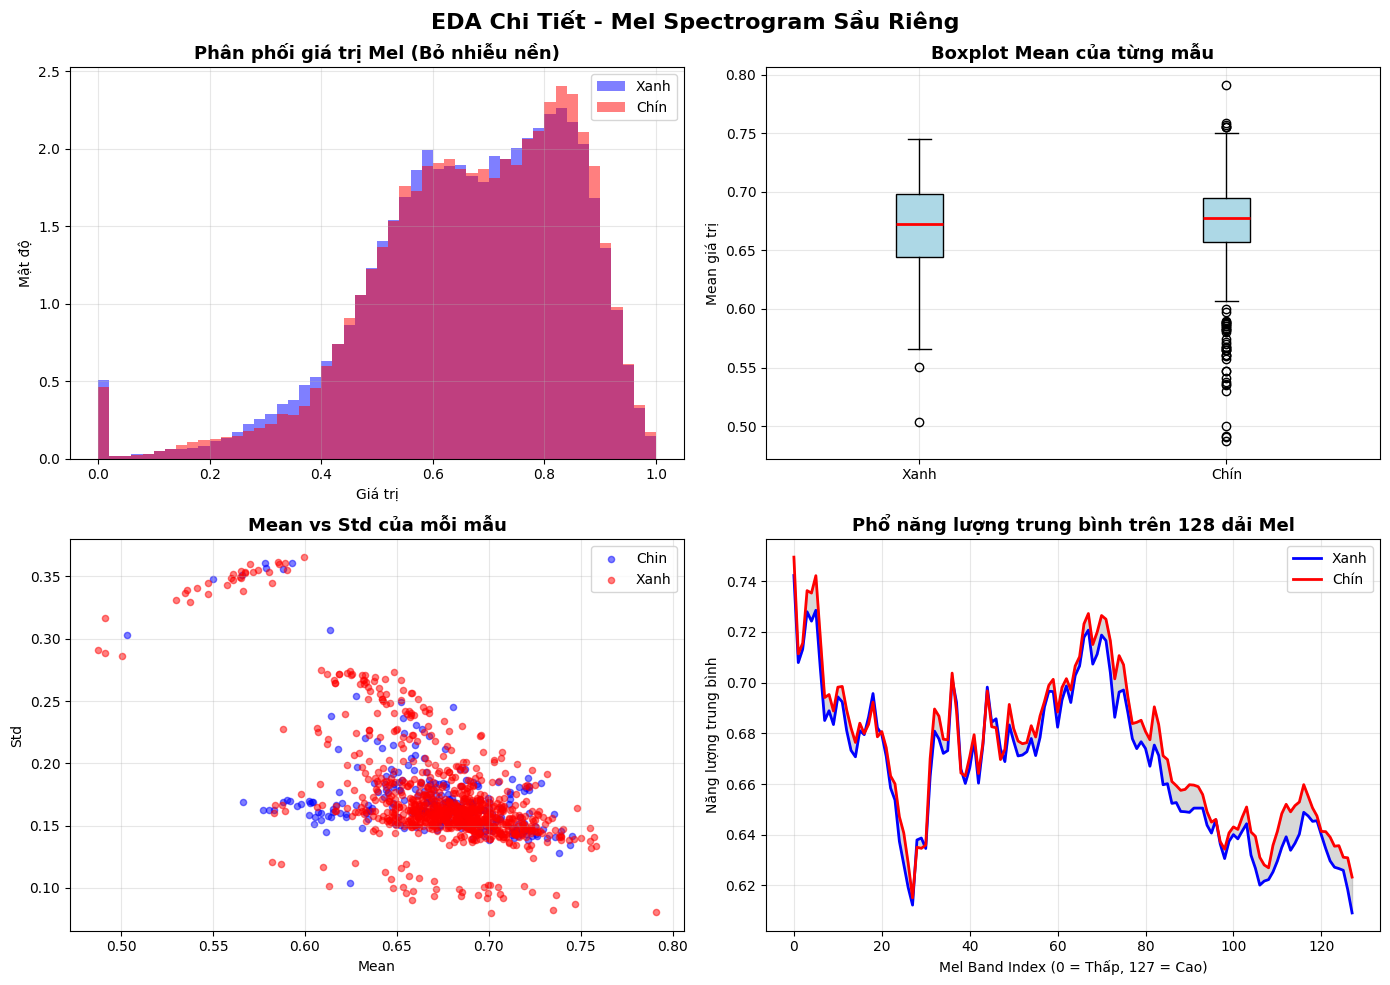

In [3]:
import matplotlib.pyplot as plt
import numpy as np

for label, name in [(1, 'chin'), (0, 'xanh')]:
    class_data = X[y == label]
    print(f"\n   {name.upper()} (Label {label}):")
    print(f"      - Số mẫu: {len(class_data):,} ({len(class_data)/len(X)*100:.1f}%)")
    print(f"      - Mean: {class_data.mean():.4f}")
    print(f"      - Std: {class_data.std():.4f}")
    print(f"      - Min: {class_data.min():.4f}")
    print(f"      - Max: {class_data.max():.4f}")

X_for_eda = X.squeeze()

means_per_sample = np.mean(X_for_eda, axis=(1, 2))
stds_per_sample = np.std(X_for_eda, axis=(1, 2))

# ===== VẼ BIỂU ĐỒ =====
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('EDA Chi Tiết - Mel Spectrogram Sầu Riêng', fontsize=16, fontweight='bold')

# 1. Histogram phân phối giá trị
ax1 = axes[0, 0]
for label, color in [(0, 'blue'), (1, 'red')]:
    data_flat = X_for_eda[y == label].flatten()
    sample = np.random.choice(data_flat, min(50000, len(data_flat)), replace=False)
    ax1.hist(sample, bins=50, alpha=0.5, color=color, label=f'{["Xanh", "Chín"][label]}', density=True)
ax1.set_title('Phân phối giá trị Mel (Bỏ nhiễu nền)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Giá trị')
ax1.set_ylabel('Mật độ')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Boxplot so sánh 2 lớp theo Mean từng mẫu
ax2 = axes[0, 1]
data_to_plot = [means_per_sample[y == 0], means_per_sample[y == 1]]
labels_plot = ['Xanh', 'Chín']
bp = ax2.boxplot(data_to_plot, tick_labels=labels_plot, patch_artist=True,
                 boxprops=dict(facecolor='lightblue'),
                 medianprops=dict(color='red', linewidth=2))
ax2.set_title('Boxplot Mean của từng mẫu', fontsize=13, fontweight='bold')
ax2.set_ylabel('Mean giá trị')
ax2.grid(True, alpha=0.3)

# 3. So sánh Mean và Std của từng mẫu (Scatter plot)
ax3 = axes[1, 0]
ax3.scatter(means_per_sample[y == 0], stds_per_sample[y == 0], alpha=0.5, color='blue', label='Chin', s=20)
ax3.scatter(means_per_sample[y == 1], stds_per_sample[y == 1], alpha=0.5, color='red', label='Xanh', s=20)
ax3.set_xlabel('Mean')
ax3.set_ylabel('Std')
ax3.set_title('Mean vs Std của mỗi mẫu', fontsize=13, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. QUAN TRỌNG NHẤT: Heatmap chênh lệch năng lượng giữa 2 lớp
ax4 = axes[1, 1]
# Tính phổ trung bình
mean_spec_xanh = np.mean(X_for_eda[y == 0], axis=(0, 2))
mean_spec_chin = np.mean(X_for_eda[y == 1], axis=(0, 2))

ax4.plot(mean_spec_xanh, color='blue', label='Xanh', linewidth=2)
ax4.plot(mean_spec_chin, color='red', label='Chín', linewidth=2)
ax4.fill_between(range(128), mean_spec_xanh, mean_spec_chin, color='gray', alpha=0.3)
ax4.set_title('Phổ năng lượng trung bình trên 128 dải Mel', fontsize=13, fontweight='bold')
ax4.set_xlabel('Mel Band Index (0 = Thấp, 127 = Cao)')
ax4.set_ylabel('Năng lượng trung bình')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

PHÂN TÍCH THEO THỜI GIAN


PHÂN TÍCH THEO THỜI GIAN (19 FRAMES)


/tmp/ipykernel_184458/3838777979.py:63: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/nghung/anaconda3/envs/Duration/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


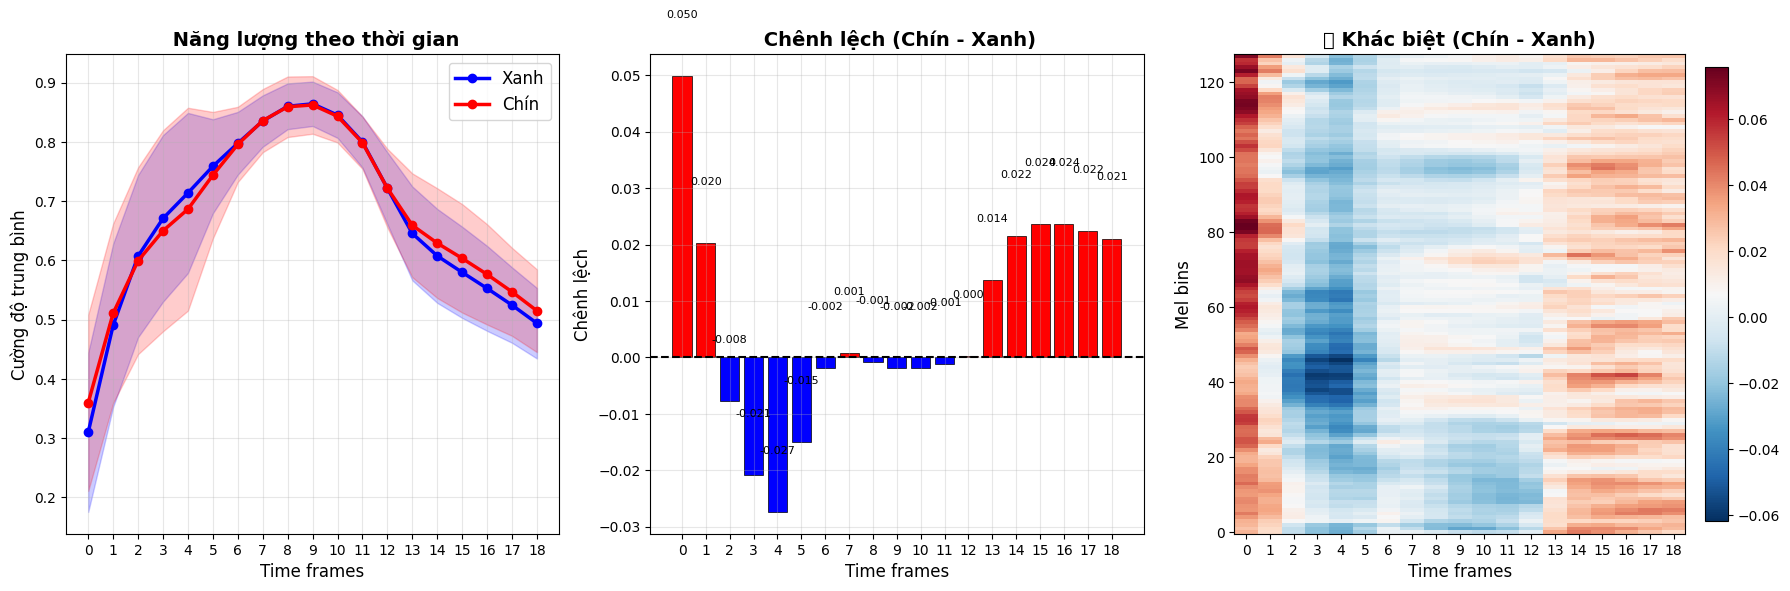


📊 CHÊNH LỆCH THEO TỪNG FRAME (Chín - Xanh)

🔍 Frame có chênh lệch LỚN NHẤT: Frame 0 (diff = 0.0498)
🔍 Frame có chênh lệch NHỎ NHẤT: Frame 12 (diff = 0.0002)


In [4]:
import matplotlib.pyplot as plt
import numpy as np

X_flat = np.squeeze(X)
print("\n" + "="*70)
print(f"PHÂN TÍCH THEO THỜI GIAN ({X_flat.shape[2]} FRAMES)")
print("="*70)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# === 1. Năng lượng trung bình theo từng frame ===
ax1 = axes[0]
for label, color, name in [(0, 'blue', 'Xanh'), (1, 'red', 'Chín')]:
    class_data = X_flat[y == label]
    # Trung bình theo mel bins cho mỗi frame
    mean_per_frame = np.mean(class_data, axis=1)  # (n_samples, time_frames)
    mean_all = np.mean(mean_per_frame, axis=0)    # (time_frames,)
    std_all = np.std(mean_per_frame, axis=0)      # (time_frames,)

    frames = range(X_flat.shape[2])
    ax1.plot(frames, mean_all, color=color, linewidth=2.5, marker='o', markersize=6, label=name)
    ax1.fill_between(frames, mean_all - std_all, mean_all + std_all,
                     alpha=0.2, color=color)
ax1.set_title(' Năng lượng theo thời gian', fontsize=14, fontweight='bold')
ax1.set_xlabel('Time frames', fontsize=12)
ax1.set_ylabel('Cường độ trung bình', fontsize=12)
ax1.set_xticks(range(X_flat.shape[2]))
ax1.legend(fontsize=12)
ax1.grid(True, alpha=0.3)

# === 2. Chênh lệch giữa 2 lớp theo từng frame ===
ax2 = axes[1]
mean_xanh = np.mean(X_flat[y == 0], axis=1)  # (n_xanh, time_frames)
mean_chin = np.mean(X_flat[y == 1], axis=1)  # (n_chin, time_frames)
diff = np.mean(mean_chin, axis=0) - np.mean(mean_xanh, axis=0)

colors_bar = ['red' if d > 0 else 'blue' for d in diff]
bars = ax2.bar(range(X_flat.shape[2]), diff, color=colors_bar, edgecolor='black', linewidth=0.5)
ax2.axhline(y=0, color='black', linestyle='--', linewidth=1.5)
ax2.set_title(' Chênh lệch (Chín - Xanh)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Time frames', fontsize=12)
ax2.set_ylabel('Chênh lệch', fontsize=12)
ax2.set_xticks(range(X_flat.shape[2]))
ax2.grid(True, alpha=0.3)

for bar, d in zip(bars, diff):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{d:.3f}', ha='center', va='bottom', fontsize=8)

# === 3. Heatmap khác biệt ===
ax3 = axes[2]
mean_xanh = np.mean(X_flat[y == 0], axis=0)  # (128, time_frames)
mean_chin = np.mean(X_flat[y == 1], axis=0)  # (128, time_frames)
diff_matrix = mean_chin - mean_xanh

im = ax3.imshow(diff_matrix, aspect='auto', origin='lower', cmap='RdBu_r')
ax3.set_title('🔥 Khác biệt (Chín - Xanh)', fontsize=14, fontweight='bold')
ax3.set_xlabel('Time frames', fontsize=12)
ax3.set_ylabel('Mel bins', fontsize=12)
ax3.set_xticks(range(X_flat.shape[2]))
plt.colorbar(im, ax=ax3, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# === IN KẾT QUẢ CHI TIẾT ===
print("\n" + "="*70)
print("📊 CHÊNH LỆCH THEO TỪNG FRAME (Chín - Xanh)")
print("="*70)

# Tính mean và std cho từng frame
mean_xanh_frame = np.mean(X_flat[y == 0], axis=1)  # (n_xanh, time_frames)
mean_chin_frame = np.mean(X_flat[y == 1], axis=1)  # (n_chin, time_frames)

# Tìm frame có chênh lệch lớn nhất
max_diff_frame = np.argmax(np.abs(diff))
print(f"\n🔍 Frame có chênh lệch LỚN NHẤT: Frame {max_diff_frame} (diff = {diff[max_diff_frame]:.4f})")
print(f"🔍 Frame có chênh lệch NHỎ NHẤT: Frame {np.argmin(np.abs(diff))} (diff = {diff[np.argmin(np.abs(diff))]:.4f})")
